# Superwell: Global Groundwater Cost & Supply Model

**Superwell** is a physics-based hydro-economic model for estimating global groundwater cost and supply. It uses the Theis equation to simulate well drawdown, supports well deepening and rate reduction, and calculates full lifecycle costs (capital, maintenance, energy) per unit volume of groundwater.

--- 

**Live notebook:** [superwell.msdlive.org](https://superwell.msdlive.org)  |  **Source code:** [github.com/JGCRI/superwell](https://github.com/JGCRI/superwell)

**Author:** Hassan Niazi — email: hassan.niazi@pnnl.gov | github [@hassaniazi](https://github.com/hassaniazi)

**Key Publications:**

1. Niazi, H., Ferencz, S. B., Graham, N. T., Yoon, J., Wild, T. B., Hejazi, M., Watson, D. J., & Vernon, C. R. (2025). [Long-term hydro-economic analysis tool for evaluating global groundwater cost and supply: Superwell v1.1](https://doi.org/10.5194/gmd-18-1737-2025). _Geoscientific Model Development, 18_(5), 1737-1767. [https://doi.org/10.5194/gmd-18-1737-2025](https://doi.org/10.5194/gmd-18-1737-2025)

2. Niazi, H., Wild, T. B., Turner, S. W. D., Graham, N. T., Hejazi, M., Msangi, S., Kim, S., Lamontagne, J. R., & Zhao, M. (2024). [Global peak water limit of future groundwater withdrawals](https://doi.org/10.1038/s41893-024-01306-w). *Nature Sustainability*, 7(4), 413–422. [https://doi.org/10.1038/s41893-024-01306-w](https://doi.org/10.1038/s41893-024-01306-w)

---

### Conceptual Framework

![Superwell Conceptual Framework](../inputs/concept.png)

*Figure: Superwell takes gridded aquifer properties and computes drawdown via the Theis equation, applies well deepening and rate reduction, calculates full lifecycle costs (capital, maintenance, energy), scales from single wells to grid cells, and generates cost–supply curves at basin, country, and continental scales.*

---

## Environment Setup

When running the github [superwell](https://github.com/JGCRI/superwell) repository, follow these:

```bash
git clone https://github.com/JGCRI/superwell.git
cd superwell/demo
python3 -m venv .venv && source .venv/bin/activate
pip install --upgrade pip
pip install -r requirements.txt
python -m ipykernel install --user --name superwell-demo
jupyter notebook superwell_quickstart.ipynb
```

For the demo, all input data is bundled in the `inputs/` directory — no downloads or git clones required.  

In [1]:
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Paths — adjust if running outside demo/
INPUTS_DIR = os.path.join('..', 'inputs')
OUTPUTS_DIR = os.path.join('..', 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'Inputs: {os.path.abspath(INPUTS_DIR)}')
print(f'Outputs: {os.path.abspath(OUTPUTS_DIR)}')

Inputs: /Users/niaz981/coding/models/jupyter-notebook-superwell/inputs
Outputs: /Users/niaz981/coding/models/jupyter-notebook-superwell/outputs


## 1. Load Inputs & Parameters

Superwell requires:
- **params.csv** — scenario settings (depletion limits, ponded depth, well design, costs)
- **inputs_recharge_lakes.csv** — gridded aquifer properties (porosity, permeability, thickness, etc.)
- **GCAM_Electricity_Rates.csv** — country-level electricity costs
- **Theis_well_function_table.csv** — W(u) lookup for the Theis solution

In [2]:
# Load all input data
grid_df = pd.read_csv(os.path.join(INPUTS_DIR, 'inputs_recharge_lakes.csv.gz'), compression='gzip')
params = pd.read_csv(os.path.join(INPUTS_DIR, 'params.csv'), index_col=0)
electricity_rates = pd.read_csv(os.path.join(INPUTS_DIR, 'GCAM_Electricity_Rates.csv'), index_col=0, header=None)
W_lookup = pd.read_csv(os.path.join(INPUTS_DIR, 'Theis_well_function_table.csv'), header='infer')

print(f'Grid cells: {len(grid_df):,}')
print(f'Countries with electricity rates: {len(electricity_rates)}')
print(f'\nParams:')
params

Grid cells: 106,432
Countries with electricity rates: 172

Params:


,Val,Notes
Index,,
Country_filter,all,NaN
Basin_filter,all,NaN
Gridcell_filter,all,8625 cell with both recharge and lakes
Total_Simulation_Years,500,years
Pumping_Days,100,days/year
Depletion_Limit,0.25,NaN
Ponded_Depth,0.3,m
Recharge_Flag,1,NaN
Shallow_Recharge_Ratio,0.2,NaN


In [3]:
# Quick look at the input data
grid_df.describe().T

,count,mean,std,min,25%,50%,75%,max
GridCellID,106432.0,5.321766e+04,3.072609e+04,1.00000,2.660875e+04,5.321650e+04,7.982425e+04,1.064390e+05
GCAM_basin_ID,106432.0,1.160754e+02,7.275771e+01,1.00000,5.100000e+01,1.250000e+02,1.840000e+02,2.350000e+02
WHYClass,106432.0,2.118395e+01,8.841061e+00,10.00000,1.000000e+01,2.000000e+01,3.000000e+01,3.000000e+01
Porosity,106432.0,1.381059e-01,5.917834e-02,0.01000,9.937500e-02,1.417073e-01,1.900000e-01,2.800000e-01
Permeability,106432.0,-1.376499e+01,7.967817e-01,-16.50000,-1.422857e+01,-1.373333e+01,-1.317143e+01,-1.090000e+01
Aquifer_thickness,106432.0,3.298149e+02,2.505558e+02,37.00000,2.000000e+02,2.668706e+02,3.762083e+02,4.665000e+03
Depth_to_water,106432.0,2.416211e+01,2.240557e+01,0.00000,7.222222e+00,1.722222e+01,3.513571e+01,1.965556e+02
Grid_area,106432.0,1.200776e+09,1.028404e+09,0.00366,9.234355e+07,1.045311e+09,2.485966e+09,2.500749e+09
Recharge,106432.0,1.088429e-01,1.399989e-01,0.00000,5.338337e-03,5.338996e-02,1.637407e-01,9.581913e-01
Lake_area,106432.0,1.984500e+07,1.131982e+08,0.00000,0.000000e+00,0.000000e+00,1.011169e+06,2.500048e+09


## 2. Run the Model (single grid cell)

For this demo, we run a **single grid cell** to show the full model workflow:  
Theis drawdown → well deepening → rate reduction → cost accounting.

The full model script is `python/superwell_deepening.py` — same physics, looped over all cells.

In [4]:
# ── Extract scenario parameters ────────────────────────────────────────────
MAX_INITIAL_SAT_THICKNESS = float(params.Val['Max_Initial_Sat_Thickness'])
DEEPENING_INCREMENT = float(params.Val['Well_Deepening_Increment'])
DEPLETION_LIMIT = float(params.Val['Depletion_Limit'])
PONDED_DEPTH_TARGET = float(params.Val['Ponded_Depth'])
RECHARGE_FLAG = int(params.Val['Recharge_Flag'])
SHALLOW_RECHARGE_RATIO = float(params.Val['Shallow_Recharge_Ratio'])
SHALLOW_RECHARGE_THRESHOLD = float(params.Val['Shallow_Recharge_Threshold'])
SPECIFIC_WEIGHT = float(params.Val['Specific_weight'])
EFFICIENCY = float(params.Val['Pump_Efficiency'])
ADJACENT_WELLS = int(params.Val['Adjacent_Wells'])
WELL_LIFETIME = float(params.Val['Max_Lifetime_in_Years'])
DEFAULT_ELECTRICITY_RATE = float(params.Val['Energy_cost_rate'])
INTEREST_RATE = float(params.Val['Interest_Rate'])
MAINTENANCE_RATE = float(params.Val['Maintenance_factor'])
NUM_YEARS = int(params.Val['Total_Simulation_Years'])
DAYS = int(params.Val['Pumping_Days'])
SECS_IN_DAY = 86400
HOURS_IN_DAY = 24

# Electricity rate dictionary
electricity_rate_dict = {
    electricity_rates.index[i].rstrip(): electricity_rates.iloc[i, 0]
    for i in range(len(electricity_rates))
}

# Candidate pumping rates (gpm → m³/s)
Q_array_gpm = [10, 20, 30, 40, 50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700, 800, 900, 1000, 1200, 1300, 1400, 1500]
Q_array = np.array(Q_array_gpm) / (60 * 264.17)

print(f'Scenario: PD={PONDED_DEPTH_TARGET}m, DL={DEPLETION_LIMIT}, {NUM_YEARS} years')

Scenario: PD=0.3m, DL=0.25, 500 years


In [5]:
# ── Theis drawdown function ────────────────────────────────────────────────
def drawdown_theis(time, r, S, T, Q):
    """Theis solution for drawdown in a confined aquifer.
    Args: time (s), r (m), S (-), T (m²/s), Q (m³/s)
    Returns: drawdown s (m)
    """
    u = r**2 * S / (4 * T * time)
    if u > 5.9:
        W = 0
    elif u > 0.6:
        idx = pd.Index(W_lookup.u)
        loc = idx.get_indexer([u], method='nearest')[0]
        W = W_lookup.W[loc]
    else:
        W = -0.57721 - math.log(u) + u - u**2 / 4
    return W * Q / (4 * math.pi * T)

In [6]:
# ── Select a demo grid cell ────────────────────────────────────────────────
# Pick grid cell 72548 (same as the sample output shipped with the repo)
DEMO_GRID_ID = 72548
demo_df = grid_df[grid_df['GridCellID'] == DEMO_GRID_ID].reset_index(drop=True)
gc = 0  # index into demo_df

print(f'Grid cell {DEMO_GRID_ID}: {demo_df.Country[gc]}, {demo_df.Basin_long_name[gc]}')
print(f'  Aquifer thickness: {demo_df.Aquifer_thickness[gc]} m')
print(f'  Depth to water:    {demo_df.Depth_to_water[gc]} m')
print(f'  Porosity:          {demo_df.Porosity[gc]}')
print(f'  Permeability:      {demo_df.Permeability[gc]} (log m²)')
print(f'  Recharge:          {demo_df.Recharge[gc]} m/yr')
print(f'  Grid area:         {demo_df.Grid_area[gc]/1e6:.1f} km²')

Grid cell 72548: Australia, Australia_East_Coast
  Aquifer thickness: 275.033333333 m
  Depth to water:    36.9166666667 m
  Porosity:          0.260416675359
  Permeability:      -12.6749999921 (log m²)
  Recharge:          0.013394772238444 m/yr
  Grid area:         2482.0 km²


In [7]:
# ── Run the full annual pumping simulation for this cell ───────────────────

# Correct for lakes
grid_area = demo_df.Grid_area[gc]
lake_area = demo_df.Lake_area[gc]
grid_area_dry = grid_area - lake_area

# Electricity rate
country = str(demo_df.Country[gc])
ELEC_RATE = electricity_rate_dict.get(country, DEFAULT_ELECTRICITY_RATE)

# Aquifer properties
total_thickness = min(demo_df.Aquifer_thickness[gc], 1000)
DTW_array = np.zeros(NUM_YEARS)
DTW_array[0] = demo_df.Depth_to_water[gc]
initial_sat_thickness = total_thickness - DTW_array[0]

sat_thickness_array = np.zeros(NUM_YEARS)
well_length_array = np.zeros(NUM_YEARS)
if initial_sat_thickness > MAX_INITIAL_SAT_THICKNESS:
    sat_thickness_array[0] = MAX_INITIAL_SAT_THICKNESS
    well_length_array[0] = sat_thickness_array[0] + DTW_array[0]
else:
    sat_thickness_array[0] = initial_sat_thickness
    well_length_array[0] = total_thickness

available_volume = initial_sat_thickness * grid_area_dry * demo_df.Porosity[gc]

S = demo_df.Porosity[gc]
K = 10 ** demo_df.Permeability[gc] * 1e7
T = K * sat_thickness_array[0]
T_array = np.zeros(NUM_YEARS)
T_array[0] = T

# ── Determine initial well Q ──
time_Q = 2 * 365 * SECS_IN_DAY
well_r = 0.5 * float(params.Val['Well_Diameter'])

s_array = np.array([drawdown_theis(time_Q, well_r, S, T, Q) for Q in Q_array])
max_s_frac, max_s_absolute = 0.40, 80

Q_viability = np.array([
    1 if (s / initial_sat_thickness < max_s_frac and s < max_s_absolute) else 0
    for s in s_array
])
assert Q_viability.sum() > 0, 'No viable pumping rates'

initial_Q = Q_array[np.max(np.where(Q_viability == 1))]
Well_Q_array = np.zeros(NUM_YEARS)
Well_Q_array[0] = initial_Q

# ── Recharge adjustments ──
recharge = demo_df.Recharge[gc]
if RECHARGE_FLAG == 0:
    NET_PONDED_DEPTH_TARGET = PONDED_DEPTH_TARGET
    deep_recharge_vol = 0
else:
    shallow_recharge_depth = SHALLOW_RECHARGE_RATIO * recharge
    threshold_depth = SHALLOW_RECHARGE_THRESHOLD * PONDED_DEPTH_TARGET
    if shallow_recharge_depth <= threshold_depth:
        NET_PONDED_DEPTH_TARGET = PONDED_DEPTH_TARGET - shallow_recharge_depth
        excessive_recharge_depth = 0
    else:
        if threshold_depth == PONDED_DEPTH_TARGET:
            NET_PONDED_DEPTH_TARGET = 0.2 * PONDED_DEPTH_TARGET
            excessive_recharge_depth = shallow_recharge_depth - threshold_depth + NET_PONDED_DEPTH_TARGET
        else:
            NET_PONDED_DEPTH_TARGET = PONDED_DEPTH_TARGET - threshold_depth
            excessive_recharge_depth = shallow_recharge_depth - threshold_depth
    deep_recharge_vol = ((1 - SHALLOW_RECHARGE_RATIO) * recharge + excessive_recharge_depth) * grid_area_dry

# ── Well area & ROI ──
initial_well_area = initial_Q * DAYS * SECS_IN_DAY / NET_PONDED_DEPTH_TARGET
initial_roi = (initial_well_area / math.pi) ** 0.5

well_roi_array = np.zeros(NUM_YEARS)
well_roi_array[0] = initial_roi
well_area_array = np.zeros(NUM_YEARS)
well_area_array[0] = initial_well_area

# ── Annual simulation ──
depleted_volume_fraction = np.zeros(NUM_YEARS)
volume_all_wells = np.zeros(NUM_YEARS)
volume_recharged = np.zeros(NUM_YEARS)
drawdown = np.zeros(NUM_YEARS)
drawdown_interference = np.zeros(NUM_YEARS)
total_head = np.zeros(NUM_YEARS)
volume_per_well = np.zeros(NUM_YEARS)
deep_recharge_vol_imposed = np.zeros(NUM_YEARS)
num_wells = np.zeros(NUM_YEARS)
cumulative_volume_per_well = np.zeros(NUM_YEARS)
cumulative_volume_all_wells = np.zeros(NUM_YEARS)

pumping_years = 0

for year in range(NUM_YEARS):
    # Depletion check
    if year > 0 and (depleted_volume_fraction[year-1] + volume_all_wells[year-1]/available_volume) > DEPLETION_LIMIT:
        break

    # Drawdown viability
    s_theis = drawdown_theis(DAYS * SECS_IN_DAY, well_r, S, T_array[year], Well_Q_array[year])
    s_interf = drawdown_theis(DAYS * SECS_IN_DAY, well_roi_array[year]*2, S, T_array[year], Well_Q_array[year])
    s_total = s_theis + ADJACENT_WELLS * s_interf

    # If constraints violated: deepen or reduce Q
    if s_total > max_s_absolute or s_total / sat_thickness_array[year] > max_s_frac:
        if well_length_array[year] < total_thickness:
            well_length_array[year] = min(well_length_array[year] + DEEPENING_INCREMENT, total_thickness)
            sat_thickness_array[year] = well_length_array[year] - DTW_array[year]
            T_array[year] = sat_thickness_array[year] * K
        else:
            s_arr = np.array([drawdown_theis(time_Q, well_r, S, T_array[year], Q) for Q in Q_array])
            qv = np.array([1 if (s/sat_thickness_array[year] < max_s_frac and s < max_s_absolute) else 0 for s in s_arr])
            if qv.sum() == 0:
                break
            Well_Q_array[year] = Q_array[np.max(np.where(qv == 1))]
            well_area_array[year] = Well_Q_array[year] * DAYS * SECS_IN_DAY / NET_PONDED_DEPTH_TARGET
            well_roi_array[year] = initial_roi

    # 10-day timestep drawdown
    s_ts = np.array([drawdown_theis((d+1)*10*SECS_IN_DAY, well_r, S, T_array[year], Well_Q_array[year]) for d in range(int(DAYS/10))])
    s_int_ts = np.array([drawdown_theis((d+1)*10*SECS_IN_DAY, well_roi_array[year]*2, S, T_array[year], Well_Q_array[year]) for d in range(int(DAYS/10))])
    s_avg = np.mean(s_ts) + ADJACENT_WELLS * np.mean(s_int_ts)

    # Jacob correction
    a = -1 / (2 * sat_thickness_array[year])
    c = -s_avg
    s_jacob = (-1 + (1 - 4*a*c)**0.5) / (2*a)
    if s_jacob == 0:
        continue

    # Record outputs
    drawdown[year] = s_jacob
    drawdown_interference[year] = ADJACENT_WELLS * np.mean(s_int_ts)
    total_head[year] = s_jacob + DTW_array[year]
    volume_per_well[year] = Well_Q_array[year] * SECS_IN_DAY * DAYS
    num_wells[year] = grid_area / well_area_array[year]
    volume_all_wells[year] = volume_per_well[year] * num_wells[year]
    cumulative_volume_per_well[year] = volume_per_well[year] + (cumulative_volume_per_well[year-1] if year > 0 else 0)
    cumulative_volume_all_wells[year] = volume_all_wells[year] + (cumulative_volume_all_wells[year-1] if year > 0 else 0)
    depleted_volume_fraction[year] = cumulative_volume_all_wells[year] / available_volume
    deep_recharge_vol_imposed[year] = min(deep_recharge_vol, volume_all_wells[year])
    pumping_years = year + 1

    # Update for next year
    if year < NUM_YEARS - 1:
        Well_Q_array[year+1] = Well_Q_array[year]
        DTW_array[year+1] = DTW_array[year] + (volume_all_wells[year] - deep_recharge_vol_imposed[year]) / grid_area_dry / S
        sat_thickness_array[year+1] = well_length_array[year] - DTW_array[year+1]
        T_array[year+1] = K * sat_thickness_array[year+1]
        well_roi_array[year+1] = well_roi_array[year]
        well_area_array[year+1] = well_area_array[year]
        well_length_array[year+1] = well_length_array[year]

print(f'Simulation ran for {pumping_years} years before hitting depletion limit ({DEPLETION_LIMIT*100}%)')
print(f'Initial Q: {initial_Q*60*264.17:.0f} gpm, Final Q: {Well_Q_array[pumping_years-1]*60*264.17:.0f} gpm')
print(f'Initial drawdown: {drawdown[0]:.1f} m, Initial depth to water: {total_head[0]:.1f} m')
print(f'Final drawdown: {drawdown[pumping_years-1]:.1f} m, Final depth to water: {total_head[pumping_years-1]:.1f} m')
print(f'Difference in depth to water: {total_head[pumping_years-1] - total_head[0]:.1f} m')
print(f'Initial number of wells: {num_wells[0]:.0f}, Final number of wells: {num_wells[pumping_years-1]:.0f}')
print(f'Initial volume per well: {volume_per_well[0]*1e6:.1f} L, Final volume per well: {volume_per_well[pumping_years-1]*1e6:.1f} L')

Simulation ran for 52 years before hitting depletion limit (25.0%)
Initial Q: 400 gpm, Final Q: 300 gpm
Initial drawdown: 80.2 m, Initial depth to water: 117.1 m
Final drawdown: 63.6 m, Final depth to water: 156.6 m
Difference in depth to water: 39.5 m
Initial number of wells: 3384, Final number of wells: 4513
Initial volume per well: 218041412726.7 L, Final volume per well: 163531059545.0 L


## 3. Visualize Single-Cell Results

Key dynamics: drawdown progression, water table decline, well deepening, and pumping rate changes.

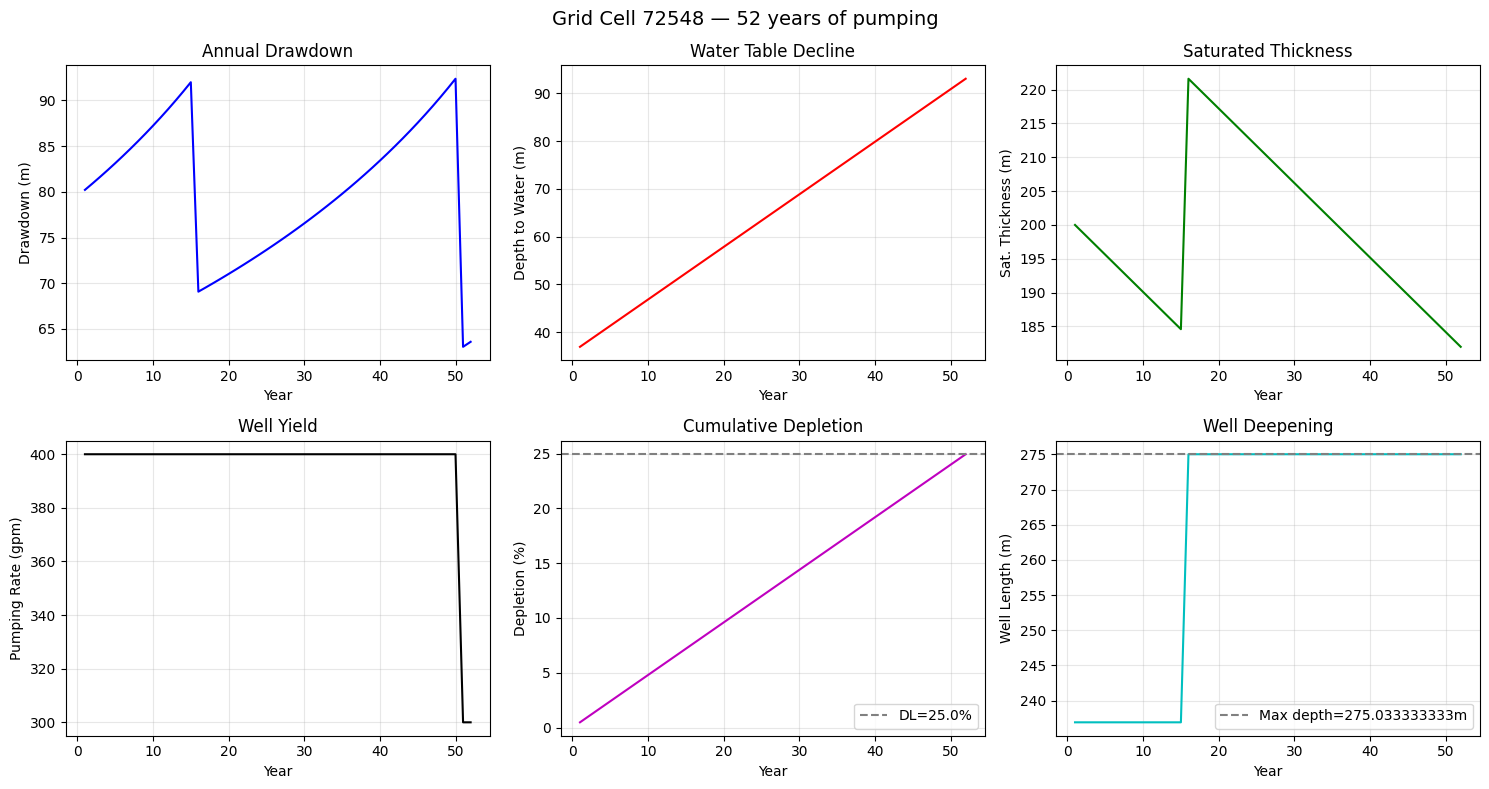

In [8]:
yrs = np.arange(1, pumping_years + 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Grid Cell {DEMO_GRID_ID} — {pumping_years} years of pumping', fontsize=14)

axes[0,0].plot(yrs, drawdown[:pumping_years], 'b-')
axes[0,0].set_ylabel('Drawdown (m)')
axes[0,0].set_title('Annual Drawdown')

axes[0,1].plot(yrs, DTW_array[:pumping_years], 'r-')
axes[0,1].set_ylabel('Depth to Water (m)')
axes[0,1].set_title('Water Table Decline')

axes[0,2].plot(yrs, sat_thickness_array[:pumping_years], 'g-')
axes[0,2].set_ylabel('Sat. Thickness (m)')
axes[0,2].set_title('Saturated Thickness')

axes[1,0].plot(yrs, Well_Q_array[:pumping_years] * 60 * 264.17, 'k-')
axes[1,0].set_ylabel('Pumping Rate (gpm)')
axes[1,0].set_title('Well Yield')

axes[1,1].plot(yrs, depleted_volume_fraction[:pumping_years] * 100, 'm-')
axes[1,1].axhline(DEPLETION_LIMIT*100, ls='--', c='gray', label=f'DL={DEPLETION_LIMIT*100}%')
axes[1,1].set_ylabel('Depletion (%)')
axes[1,1].set_title('Cumulative Depletion')
axes[1,1].legend()

axes[1,2].plot(yrs, well_length_array[:pumping_years], 'c-')
axes[1,2].axhline(total_thickness, ls='--', c='gray', label=f'Max depth={total_thickness}m')
axes[1,2].set_ylabel('Well Length (m)')
axes[1,2].set_title('Well Deepening')
axes[1,2].legend()

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, f'demo_grid_cell_{DEMO_GRID_ID}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Run Full Model (all cells)

The production model runs the same logic over all ~72k grid cells.  
Run it directly from the command line:

In [9]:
# Uncomment to run the full model (takes several minutes for all cells):
# %run ../python/superwell_deepening.py

## 5. Analyze Sample Outputs (100 Grid Cells)

Load the pre-computed multi-cell sample to explore complex emergent dynamics across diverse aquifer settings.

In [10]:
# Load pre-computed sample output (100 sampled grid cells)
output_file = os.path.join(OUTPUTS_DIR, 'superwell_py_deep_all_0.3PD_0.25DL_sample_100.csv')
results = pd.read_csv(output_file)
results.columns = results.columns.str.strip()
print(f'Output rows: {len(results):,}, columns: {len(results.columns)}')
print(f'Unique grid cells: {results.grid_id.nunique()}')
print(f'Year range: {results.year_number.min()}–{results.year_number.max()}')
print(f'Pumping lifetime by cell (years):')
print(results.groupby('grid_id')['year_number'].max().describe().to_string())
results.head()

Output rows: 2,309, columns: 45
Unique grid cells: 55
Year range: 1–179
Pumping lifetime by cell (years):
count     55.000000
mean      41.981818
std       32.245293
min        3.000000
25%       24.000000
50%       32.000000
75%       50.000000
max      179.000000


,year_number,depletion_limit,continent,country,gcam_basin_id,Basin_long_name,grid_id,grid_area,permeability,porosity,...,energy,energy_cost_rate,energy_cost,total_cost_perwell,total_cost_allwells,unit_cost,unit_cost_per_km3,unit_cost_per_acreft,whyclass,total_well_length
0,1,0.25,USA,USA,1,USA,1,1.220373e+09,-13.114678,0.11,...,1.616776e+08,0.074,1.196414e+07,6225.656520,2.787588e+07,0.076140,7.614036e+07,93.917606,10,231.122085
1,2,0.25,USA,USA,1,USA,1,1.220373e+09,-13.114678,0.11,...,1.682023e+08,0.074,1.244697e+07,6333.489207,2.835871e+07,0.077459,7.745916e+07,95.544324,10,231.122085
2,3,0.25,USA,USA,1,USA,1,1.220373e+09,-13.114678,0.11,...,1.749028e+08,0.074,1.294281e+07,6444.227012,2.885455e+07,0.078813,7.881349e+07,97.214867,10,231.122085
3,4,0.25,USA,USA,1,USA,1,1.220373e+09,-13.114678,0.11,...,1.818030e+08,0.074,1.345342e+07,6558.265255,2.936516e+07,0.080208,8.020819e+07,98.935200,10,231.122085
4,5,0.25,USA,USA,1,USA,1,1.220373e+09,-13.114678,0.11,...,1.889323e+08,0.074,1.398099e+07,6676.090114,2.989273e+07,0.081649,8.164920e+07,100.712656,10,231.122085


**Sampled input properties** for 100 representative grid cells:

<img src="../inputs/sampled_data_100.png" alt="Superwell Sampled Inputs" width="40%">

Sampled input properties across 100 representative grid cells, showing the diversity of aquifer conditions (permeability, thickness, porosity) that drive different cost–supply outcomes in Superwell. Each point represents a grid cell with unique hydrogeological characteristics.

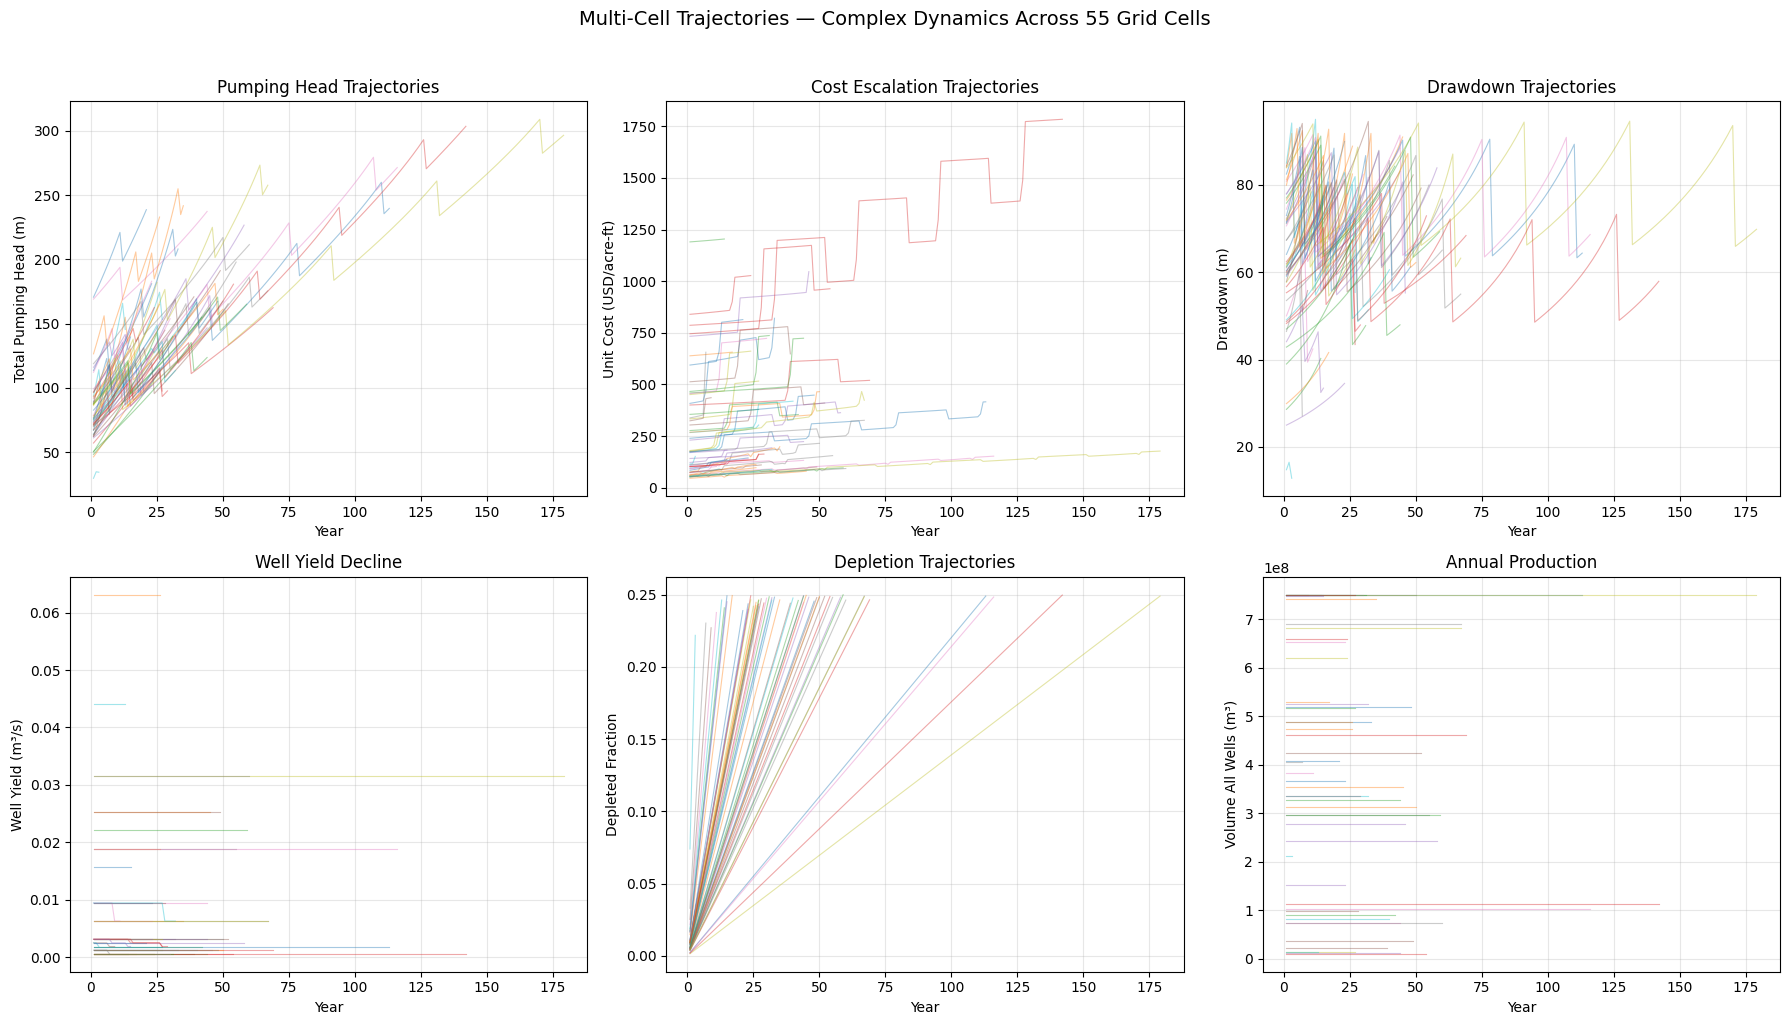

In [11]:
# ── 5a. Spaghetti Plots: Per-Cell Trajectories ──────────────────────────────
# Each line = one grid cell's trajectory over time → reveals heterogeneity

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Cell Trajectories — Complex Dynamics Across 55 Grid Cells', fontsize=14, y=1.02)

metrics = [
    ('total_head', 'Total Pumping Head (m)', 'Pumping Head Trajectories'),
    ('unit_cost_per_acreft', 'Unit Cost (USD/acre-ft)', 'Cost Escalation Trajectories'),
    ('drawdown', 'Drawdown (m)', 'Drawdown Trajectories'),
    ('well_yield', 'Well Yield (m³/s)', 'Well Yield Decline'),
    ('depleted_vol_fraction', 'Depleted Fraction', 'Depletion Trajectories'),
    ('volume_produced_allwells', 'Volume All Wells (m³)', 'Annual Production'),
]

for ax, (col, ylabel, title) in zip(axes.flat, metrics):
    for gid, grp in results.groupby('grid_id'):
        ax.plot(grp.year_number, grp[col], alpha=0.4, linewidth=0.8)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

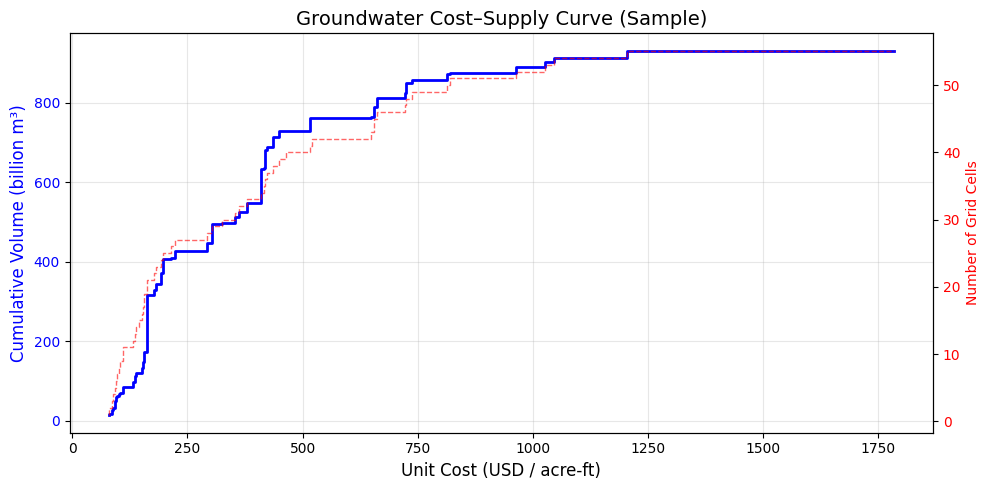

In [12]:
# ── 5b. Cost–Supply Curve (cumulative) ───────────────────────────────────────
# Aggregates across all cells: sort year-final unit costs, accumulate volumes
# This is the signature Superwell output — a groundwater supply curve

final_year = results.loc[results.groupby('grid_id')['year_number'].idxmax()]
sorted_cells = final_year.sort_values('unit_cost_per_acreft')

fig, ax1 = plt.subplots(figsize=(10, 5))
cum_vol = sorted_cells['cumulative_vol_produced_allwells'].cumsum() / 1e9  # km³
ax1.step(sorted_cells['unit_cost_per_acreft'].values, cum_vol.values, 'b-', linewidth=2)
ax1.set_xlabel('Unit Cost (USD / acre-ft)', fontsize=12)
ax1.set_ylabel('Cumulative Volume (billion m³)', fontsize=12, color='b')
ax1.set_title('Groundwater Cost–Supply Curve (Sample)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.step(sorted_cells['unit_cost_per_acreft'].values,
         np.arange(1, len(sorted_cells)+1), 'r--', alpha=0.6, linewidth=1)
ax2.set_ylabel('Number of Grid Cells', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.tight_layout()
plt.show()

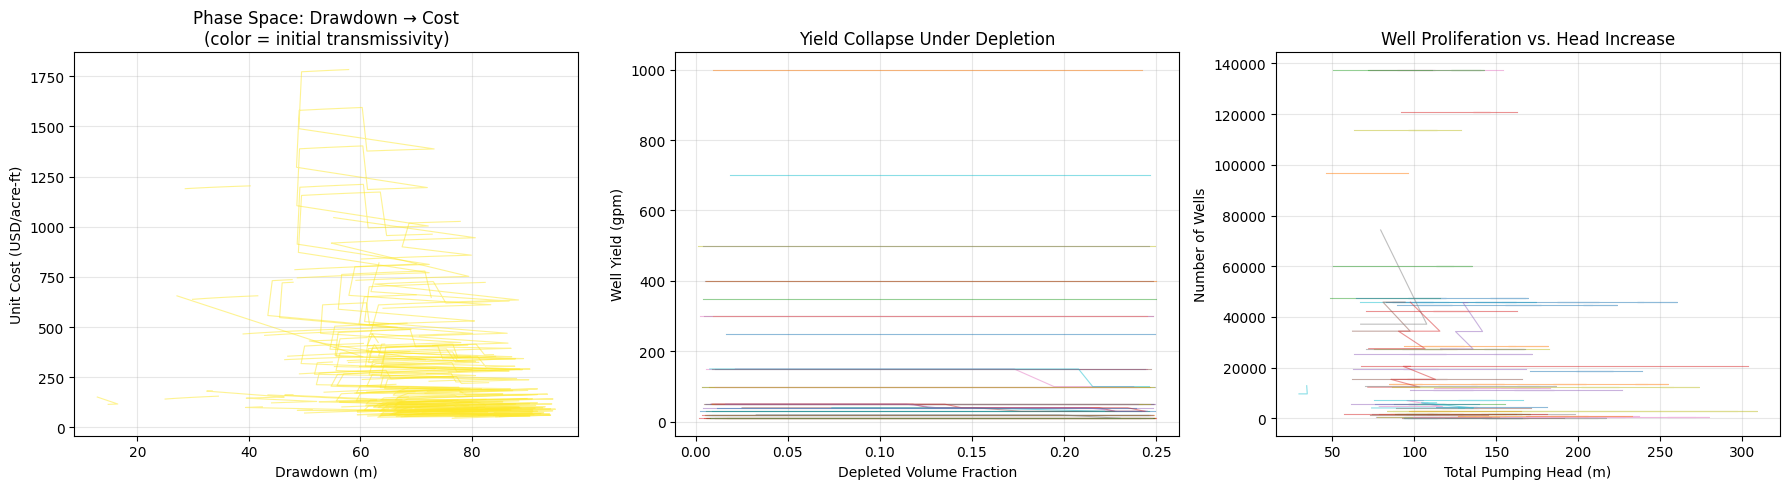

In [13]:
# ── 5c. Phase-Space Diagrams: Nonlinear Feedbacks ────────────────────────────
# Drawdown vs. Cost reveals the nonlinear coupling between physical depletion
# and economic cost — wells in different aquifer regimes trace distinct loops

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phase space: drawdown vs unit cost (colored by transmissivity)
for gid, grp in results.groupby('grid_id'):
    T0 = grp.transmissivity.iloc[0]
    color = plt.cm.viridis(np.log10(T0 + 1e-10) / np.log10(results.transmissivity.max() + 1e-10))
    axes[0].plot(grp.drawdown, grp.unit_cost_per_acreft, '-', alpha=0.5, color=color, linewidth=0.8)
axes[0].set_xlabel('Drawdown (m)')
axes[0].set_ylabel('Unit Cost (USD/acre-ft)')
axes[0].set_title('Phase Space: Drawdown → Cost\n(color = initial transmissivity)')
axes[0].grid(True, alpha=0.3)

# Phase space: depleted fraction vs well yield
for gid, grp in results.groupby('grid_id'):
    axes[1].plot(grp.depleted_vol_fraction, grp.well_yield * 60 * 264.17,
                 '-', alpha=0.5, linewidth=0.8)
axes[1].set_xlabel('Depleted Volume Fraction')
axes[1].set_ylabel('Well Yield (gpm)')
axes[1].set_title('Yield Collapse Under Depletion')
axes[1].grid(True, alpha=0.3)

# Phase space: total head vs number of wells
for gid, grp in results.groupby('grid_id'):
    axes[2].plot(grp.total_head, grp.number_of_wells, '-', alpha=0.5, linewidth=0.8)
axes[2].set_xlabel('Total Pumping Head (m)')
axes[2].set_ylabel('Number of Wells')
axes[2].set_title('Well Proliferation vs. Head Increase')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

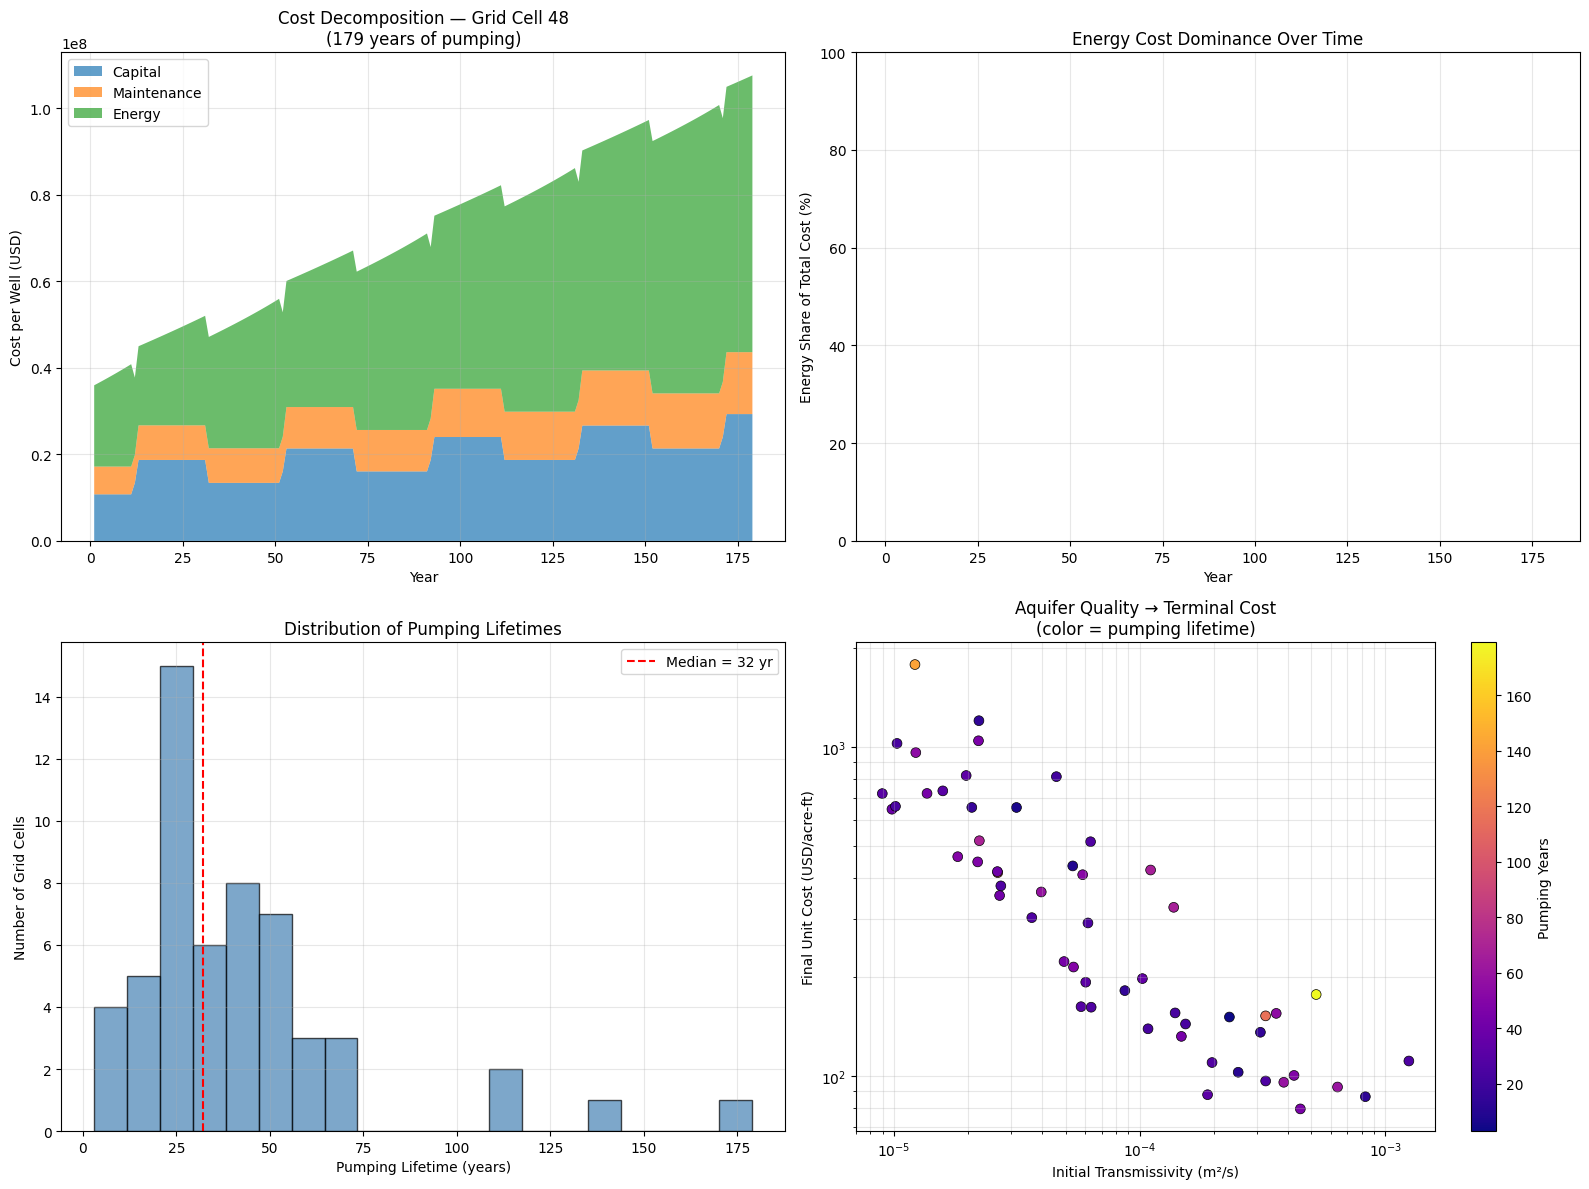

In [14]:
# ── 5d. Cost Decomposition & Regime Transitions ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (i) Stacked cost breakdown for the longest-running cell
longest_cell = results.groupby('grid_id')['year_number'].max().idxmax()
cell_data = results[results.grid_id == longest_cell].copy()

axes[0,0].stackplot(cell_data.year_number,
                     cell_data['annual_capital_cost'],
                     cell_data['maintenance_cost'],
                     cell_data['energy_cost'],
                     labels=['Capital', 'Maintenance', 'Energy'],
                     alpha=0.7)
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Cost per Well (USD)')
axes[0,0].set_title(f'Cost Decomposition — Grid Cell {longest_cell}\n({len(cell_data)} years of pumping)')
axes[0,0].legend(loc='upper left')
axes[0,0].grid(True, alpha=0.3)

# (ii) Energy fraction of total cost across all cells over time
results['energy_fraction'] = results['energy_cost'] / (results['total_cost_perwell'] + 1e-10)
for gid, grp in results.groupby('grid_id'):
    axes[0,1].plot(grp.year_number, grp.energy_fraction * 100, alpha=0.4, linewidth=0.8)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Energy Share of Total Cost (%)')
axes[0,1].set_title('Energy Cost Dominance Over Time')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim(0, 100)

# (iii) Histogram: pumping lifetime distribution
lifetimes = results.groupby('grid_id')['year_number'].max()
axes[1,0].hist(lifetimes, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1,0].axvline(lifetimes.median(), color='red', linestyle='--', label=f'Median = {lifetimes.median():.0f} yr')
axes[1,0].set_xlabel('Pumping Lifetime (years)')
axes[1,0].set_ylabel('Number of Grid Cells')
axes[1,0].set_title('Distribution of Pumping Lifetimes')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# (iv) Scatter: initial transmissivity vs final unit cost (log-log)
first_year = results.loc[results.groupby('grid_id')['year_number'].idxmin()]
last_year = results.loc[results.groupby('grid_id')['year_number'].idxmax()]
merged = first_year[['grid_id', 'transmissivity', 'porosity', 'orig_aqfr_sat_thickness']].merge(
    last_year[['grid_id', 'unit_cost_per_acreft', 'year_number']], on='grid_id')

sc = axes[1,1].scatter(merged.transmissivity, merged.unit_cost_per_acreft,
                        c=merged.year_number, cmap='plasma', s=50, edgecolors='k', linewidths=0.5)
axes[1,1].set_xscale('log')
axes[1,1].set_yscale('log')
axes[1,1].set_xlabel('Initial Transmissivity (m²/s)')
axes[1,1].set_ylabel('Final Unit Cost (USD/acre-ft)')
axes[1,1].set_title('Aquifer Quality → Terminal Cost\n(color = pumping lifetime)')
plt.colorbar(sc, ax=axes[1,1], label='Pumping Years')
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

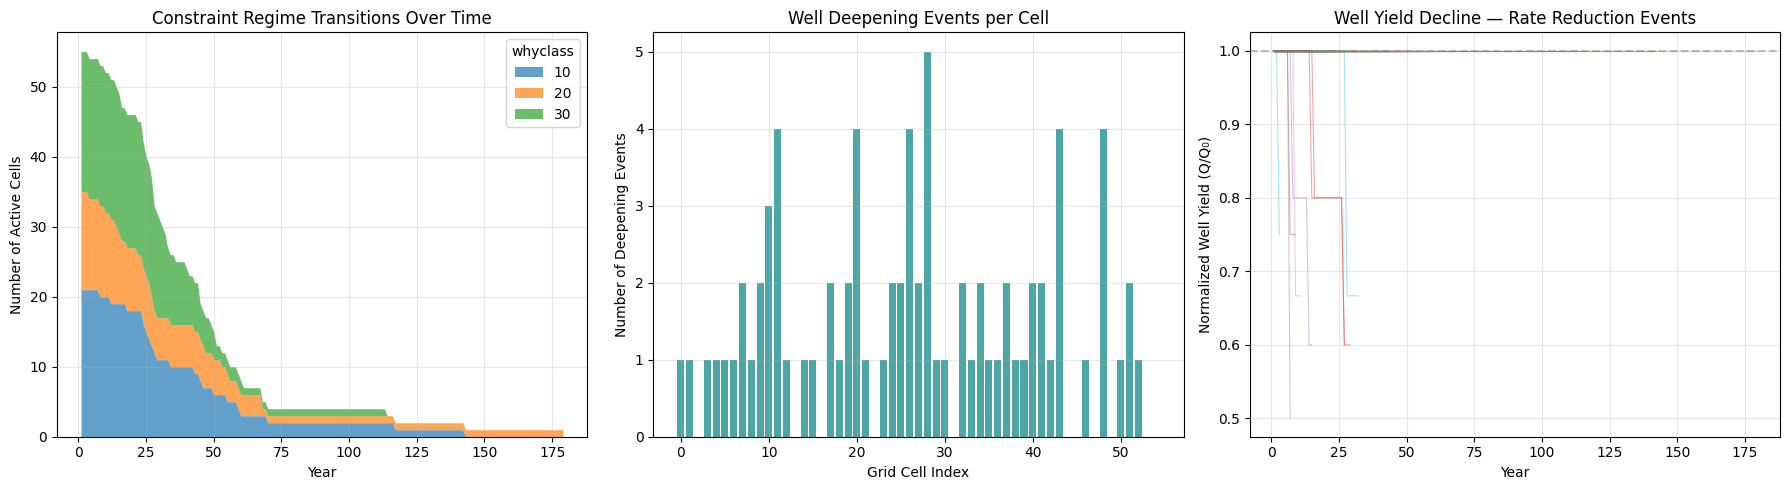

In [15]:
# ── 5e. Regime Classification: Deepening vs Rate Reduction ──────────────────
# Cells that hit the aquifer bottom must reduce pumping rate → different cost path
# "whyclass" column encodes the constraint regime

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (i) Regime breakdown over time — stacked area
regime_counts = results.groupby(['year_number', 'whyclass']).size().unstack(fill_value=0)
regime_counts.plot.area(ax=axes[0], alpha=0.7, linewidth=0)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Active Cells')
axes[0].set_title('Constraint Regime Transitions Over Time')
axes[0].grid(True, alpha=0.3)

# (ii) Well deepening events — detect year-over-year well length changes
fig2_data = []
for gid, grp in results.groupby('grid_id'):
    grp = grp.sort_values('year_number')
    length_changes = grp.total_well_length.diff().fillna(0)
    deepening_events = (length_changes > 0).sum()
    max_depth = grp.total_well_length.max()
    fig2_data.append({'grid_id': gid, 'deepening_events': deepening_events, 'max_depth': max_depth})
deep_df = pd.DataFrame(fig2_data)

axes[1].bar(range(len(deep_df)), deep_df.deepening_events.values, color='teal', alpha=0.7)
axes[1].set_xlabel('Grid Cell Index')
axes[1].set_ylabel('Number of Deepening Events')
axes[1].set_title('Well Deepening Events per Cell')
axes[1].grid(True, alpha=0.3)

# (iii) Rate reduction trajectory — normalized yield over time
for gid, grp in results.groupby('grid_id'):
    grp = grp.sort_values('year_number')
    initial_yield = grp.well_yield.iloc[0]
    if initial_yield > 0:
        axes[2].plot(grp.year_number, grp.well_yield / initial_yield, alpha=0.4, linewidth=0.8)
axes[2].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Normalized Well Yield (Q/Q₀)')
axes[2].set_title('Well Yield Decline — Rate Reduction Events')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

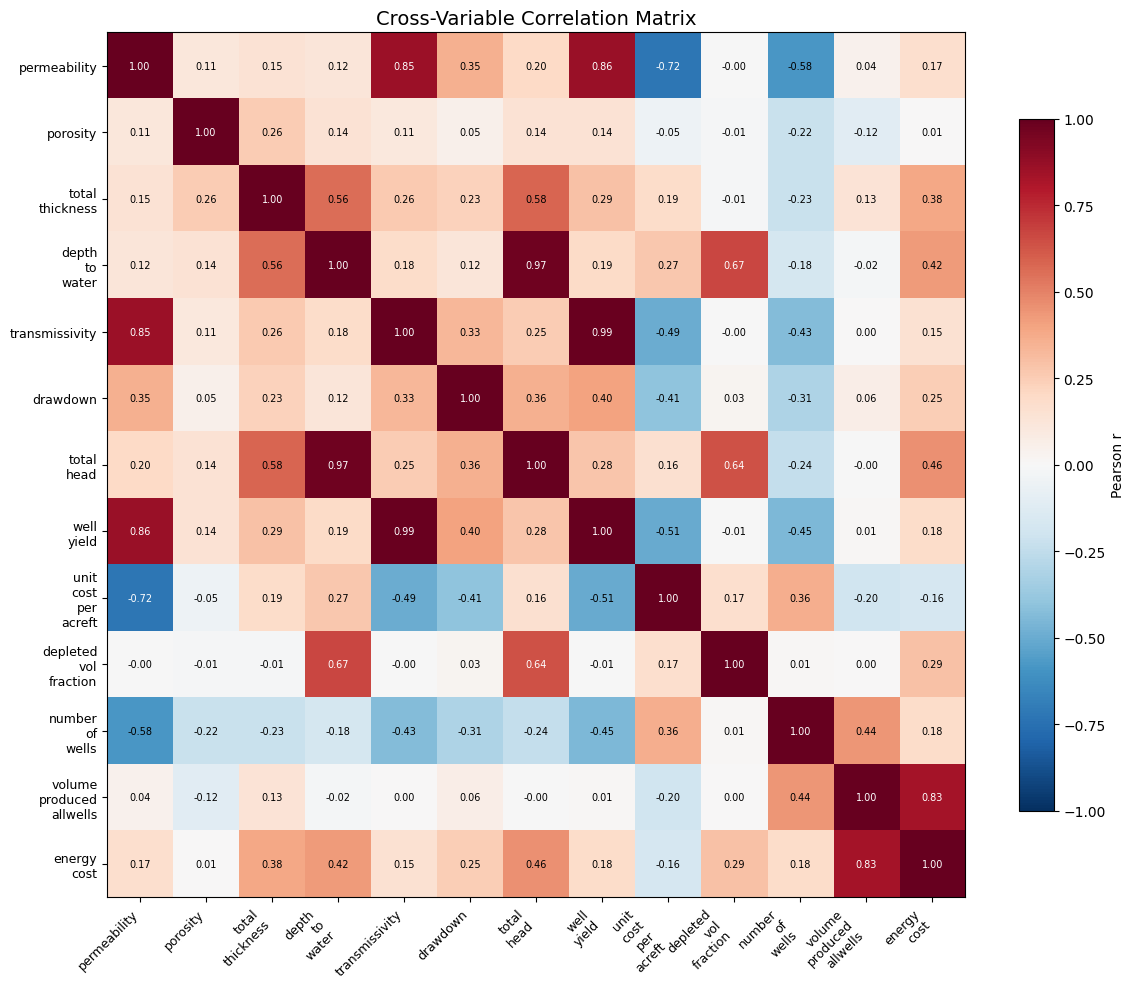

In [16]:
# ── 5f. Cross-Cell Correlation Heatmap ───────────────────────────────────────
# Reveals which aquifer properties drive which outcomes

corr_cols = ['permeability', 'porosity', 'total_thickness', 'depth_to_water',
             'transmissivity', 'drawdown', 'total_head', 'well_yield',
             'unit_cost_per_acreft', 'depleted_vol_fraction',
             'number_of_wells', 'volume_produced_allwells', 'energy_cost']
corr_data = results[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in corr_cols], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([c.replace('_', '\n') for c in corr_cols], fontsize=9)
ax.set_title('Cross-Variable Correlation Matrix', fontsize=14)

# Annotate cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Key Model Concepts

| Concept | Description |
|---------|-------------|
| **Theis Equation** | Analytical solution for transient drawdown in confined aquifers |
| **Well Deepening** | Wells are incrementally deepened (default 50m) when drawdown constraints are violated |
| **Rate Reduction** | Once fully deepened, pumping rate is reduced to meet drawdown constraints |
| **Jacob Correction** | Converts Theis (confined) drawdown to unconfined conditions |
| **Interference** | Accounts for drawdown from adjacent wells (default 6 neighbors) |
| **Recharge** | Splits into shallow (reduces pumping need) and deep (replenishes storage) |
| **Depletion Limit** | Fraction of available volume that can be extracted (scenario parameter) |
| **Cost Model** | Capital (well install + deepening), maintenance (% of capital), energy (power × rate) |

---

**Next steps:** Modify `inputs/params.csv` to design your own scenarios, or run the full model with the Superwell package.

---

## References & Contact

### Publications

1. Niazi, H., Ferencz, S. B., Graham, N. T., Yoon, J., Wild, T. B., Hejazi, M., Watson, D. J., & Vernon, C. R. (2025). [Long-term hydro-economic analysis tool for evaluating global groundwater cost and supply: Superwell v1.1](https://doi.org/10.5194/gmd-18-1737-2025). _Geoscientific Model Development, 18_(5), 1737-1767. [https://doi.org/10.5194/gmd-18-1737-2025](https://doi.org/10.5194/gmd-18-1737-2025)

2. Niazi, H., Wild, T. B., Turner, S. W. D., Graham, N. T., Hejazi, M., Msangi, S., Kim, S., Lamontagne, J. R., & Zhao, M. (2024). [Global peak water limit of future groundwater withdrawals](https://doi.org/10.1038/s41893-024-01306-w). *Nature Sustainability*, 7(4), 413–422. [https://doi.org/10.1038/s41893-024-01306-w](https://doi.org/10.1038/s41893-024-01306-w)

### Links

- **Superwell Source:** [github.com/JGCRI/superwell](https://github.com/JGCRI/superwell)
- **Live Notebook:** [superwell.msdlive.org](https://superwell.msdlive.org)

### Contact

- **Author:** Hassan Niazi — email hassan.niazi@pnnl.gov | github [@hassaniazi](https://github.com/hassaniazi)